In [32]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import sys
from scipy.stats import norm, poisson, chi2
from scipy.integrate import quad
from iminuit import Minuit
from iminuit.cost import LeastSquares

In [33]:
def plot_fit (x_coord, y_coord, y_sigma, fit_function, minuit_object , title = '') :
    """
    Plots the data and the best-fit function using iminuit fit results.

    Parameters:
    - x_coord: array of x values (data)
    - y_coord: array of y values (data)
    - y_sigma: aray of y uncertainties (data)
    - fit_function: the model function used for fitting
    - minuit_object: the iminuit Minuit instance after fitting
    """
    fig, ax = plt.subplots ()
    ax.errorbar (x_coord, y_coord, xerr = 0.0, yerr = y_sigma, linestyle = 'None', marker = 'o', label='dati sperimentali')

    x_fit = np.linspace (x_coord[0] -15, x_coord[-1]+15, 100)
    best_params = {key: minuit_object.values[key] for key in minuit_object.parameters}
    y_fit = fit_function (x_fit, **best_params)  # Evaluate function with best-fit params
    ax.plot (x_fit, y_fit, color="forestgreen", linewidth=2, label= 'fit')
    ax.set_xlabel (" N ")
    ax.set_ylabel ("cos(theta)")
    ax.set_title (title)
     #plt.legend('a = 1.585 ± 0.009' , 'b=0.10117 ± 0.01879μm2')
    #plt.savefig("R=5k_cb_C1.png")
    ax.legend()
    plt.grid(True)
    plt.show()
    #plt.close(fig)

In [34]:
#parte 1
#N = [15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1] #numero di frangia (1 = cerchio più lontano) dati completi
#R_N = [1.2, 2.0, 2.5, 2.9, 3.4, 3.7, 4.0 ,4.3, 4.5, 4.8, 5.1, 5.3, 5.6, 5.8, 6.0] #cm - raggio dei cerchi di interferenza dati completi
#N_tot =15


In [35]:
lamda = 632.8e-9 #m - lunghezza d'onda del laser è nota
#grandezze misurate
L0 = 1.37 #m - distanza dall’equivalente sorgente (punto virtuale tra specchi) allo schermo
N = [15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1] #numero di frangia (1 = cerchio più lontano)
R_N_2 = [0.015, 0.023, 0.0275, 0.032, 0.036, 0.0395, 0.0425, 0.0455, 0.0480, 0.0510, 0.0535, 0.056, 0.0585, 0.0605, 0.0625]
err_RN = 0.0005  #m - mezzo mm di errore (righello)
N_tot = len(N)
R_N = [0.012, 0.020, 0.025, 0.029, 0.034, 0.037, 0.040 ,0.043, 0.045, 0.048, 0.051, 0.053, 0.056, 0.058, 0.060] #m - raggio dei cerchi di interferenza
theta_N = []
cos_theta = []
d_reale = []

In [36]:
def theta (R_N):
    return np.arctan(R_N/L0)

def costheta (theta):
    return np.cos(theta)


for i in range (N_tot):
    theta_N.append(theta(R_N[i]))
theta_N = np.array(theta_N)

for i in range (N_tot):
    cos_theta.append(costheta(theta_N[i]))
cos_theta = np.array(cos_theta)

print (theta_N, cos_theta)

[0.0087589  0.0145975  0.01824615 0.02116472 0.02481243 0.02700074
 0.02918879 0.03137656 0.03283491 0.03502217 0.0372091  0.03866685
 0.04085317 0.0423105  0.04376765] [0.99996164 0.99989346 0.99983354 0.99977604 0.99969219 0.9996355
 0.99957404 0.9995078  0.99946098 0.99938679 0.99930782 0.99925253
 0.99916563 0.99910504 0.99904235]


In [37]:
#a = lamda/(2*d_reale) ------> trovo d
#b = -delta_r/(4*np.pi*d) ------> trovo delta r
#def maxtheta (N , d, b):
    #return (N*lamda)/(2*d) +b

def max_theta (N, a, b):
    return a*N + b

In [38]:
#minimi quadrati con a e b
least_squares = LeastSquares (N, cos_theta, 0.00001, max_theta)
my_minuit1 = Minuit (least_squares, a= 0.0, b= 0.0)
my_minuit1.migrad ()
my_minuit1.hesse ()


is_valid = my_minuit1.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit1.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit1.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit1.fval, df = my_minuit1.ndof))

for par, val, err in zip (my_minuit1.parameters, my_minuit1.values, my_minuit1.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

a_fit = my_minuit1.values[0]
a_err = my_minuit1.errors[0]
b_fit = my_minuit1.values[1]
b_err =my_minuit1.errors[1]


print (my_minuit1.covariance)


display (my_minuit1)

success of the fit:  True
value of the fit Q-squared 11.075971920174684
value of the number of degrees of freedom 13.0
associated p-value:  0.6044531848768561
a = 0.000 +/- 0.000
b = 0.999 +/- 0.000
┌───┬───────────────────┐
│   │        a        b │
├───┼───────────────────┤
│ a │ 3.58e-13 -2.9e-12 │
│ b │ -2.9e-12 2.96e-11 │
└───┴───────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 11.08 (χ²/ndof = 0.9)      │              Nfcn = 54               │
│ EDM = 7.07e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │  65.6e-6  │  0.6e-6   │            │            │         │         │       │
│ 1 │ b    │998.982e-3 │ 0.005e-3  │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        a        b │
├───┼───────────────────┤
│ a │ 3.58e-13 -2.9e-12 │
│ b │ -2.9e-12 2.96e-11 │
└───┴───────────────────┘

In [39]:
print (a_fit, b_fit)
print(lamda)
#a = lamda/(2*d) ------> trovo d
#b = -delta_r/(4*np.pi*d) ------> trovo delta r
d = lamda/(2*a_fit)
delta_r = -b_fit*4*np.pi

print (d, delta_r)


6.558115697297834e-05 0.9989817068947306
6.328e-07
0.004824556543434687 -12.55357436580431


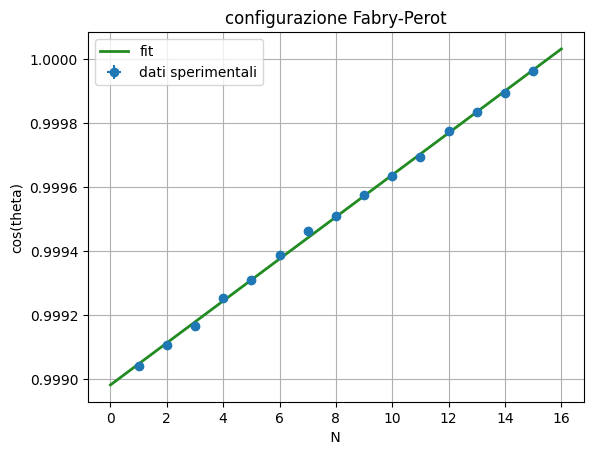

In [40]:
#fit lineari
#plot fit 1
plot_fit(N, cos_theta ,0.00001 ,max_theta , my_minuit1, "configurazione Fabry-Perot")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)


In [41]:
#mettere i valori ricavati a e b e fare i eventuali t student

In [42]:
#parte 2 micrometro calibrazione

In [43]:
def d_real (cos_theta):
    return (delta_N * lamda)/(2*cos_theta)

In [44]:
d_mm_nom = 20*10e-6 #spostamento in mum dello specchio mobile
delta_N = 49
costet=1


D_reale_fp = d_real(costet) #distanza tra i due specchi
print (D_reale_fp)

1.55036e-05


In [45]:
fattore_di_calibrazione_fabry_perot = D_reale_fp/d_mm_nom #per avere il vero spostamento bisogna applicare questo fattore di correzione
k_cor_fp = fattore_di_calibrazione_fabry_perot
print(k_cor_fp)

0.07751799999999999


In [46]:
#parte Michealson

In [47]:
#calibrazione micrometro

In [48]:
d_mm_nom = 20*10e-6 #spostamento in mum dello specchio mobile
delta_N = 47 #numero di frange
costet=1


D_reale_M = d_real(costet) #distanza tra i due specchi
print (D_reale_M)

1.48708e-05


In [49]:
fattore_di_calibrazione_michealson = D_reale_M/d_mm_nom #per avere il vero spostamento bisogna applicare questo fattore di correzione
k_cor_M = fattore_di_calibrazione_michealson
print(k_cor_M)

0.07435399999999999


In [50]:
#confonto tra i due fattori di conversione (Fabry-Perot vs Michealson)
print (k_cor_fp)
print (k_cor_M)
print ('meglio Michealson')

0.07751799999999999
0.07435399999999999
meglio Michealson


In [51]:
#indice di rifrazione dell'aria

In [52]:
s_a = 0.03 #spessore cella (PASCO)
Pi = 101325 #Pa - pressione atmosferica
Pf = 101325-76000 #Pa
delta_P = Pi - Pf
N_fa = 17


In [53]:
def maria (N_fa, delta_P):
    return (N_fa * lamda)/(2*s_a*delta_P)

m_aria = maria(N_fa, delta_P)
n_aria = m_aria * Pi +1

#def naria (N_fa, cos_theta):
    #return ((2*d-N_fa*lamda)*(1-cos_theta))/((2*d)*(1-cos_theta)-(N_fa*lamda))
#n_aria = naria (N_fa, cos_theta_M)
print (m_aria, n_aria)

2.359122807017544e-09 1.000239038118421


In [54]:
#indice di rifrazione del vetro

In [55]:
s_v = 0.0025 #m
theta_i = np.radians(25)
theta_f = np.radians(0)
N_fv = 850 # parte da rivedere
delta_theta = theta_i - theta_f
cos_dtheta = np.cos(delta_theta)

In [56]:
def nvetro (N_fa, cos_theta, d):
    return ((2*d-N_fa*lamda)*(1-cos_theta))/((2*d)*(1-cos_theta)-(N_fa*lamda))

n_vetro= nvetro(N_fv, cos_dtheta, s_v)
print (n_vetro)

-6.02236113539379


In [57]:
#parte righello

In [58]:
d_rig = 0.0005 #m - passo del righello = 1 mm
L_r = 1.20 #m - distanza schermo-righello
P0 = 0.08 #m
Pt = -0.08
delta_Pt_P0 = P0 - Pt
N_r = [0, 1,2,3,4,5,6,7,8,9,10,11,12,13] #n bande
Pn = [0.08, 0.1085, 0.1285, 0.1450, 0.1595, 0.173, 0.186, 0.198, 0.209, 0.218, 0.228, 0.238, 0.2475, 0.2570] #m - distanza dallo 0 (parto da n=1)

In [59]:
def thetai (P0):
    return np.arctan(P0/L_r)

def thetan (delta_xN):
    return np.arctan(delta_xN/L_r)


theta_n= []
for i in range(len(N_r)):
    theta_n.append(thetan(Pn[i]))

theta_n= np.array(theta_n)
theta_i = thetai(P0)

#print (theta_n, theta_i)

In [60]:
cos_theta_i = np.cos(theta_i)
cos_theta_n = []

for i in range (len(theta_n)):
    cos_theta_n.append(np.cos(theta_n[i]))

cos_theta_n = np.array(cos_theta_n)

print (cos_theta_n, cos_theta_i)


[0.99778516 0.99593731 0.99431542 0.99277863 0.99128193 0.98976722
 0.98819971 0.98665929 0.98516955 0.98389614 0.98242445 0.9808938
 0.97938587 0.97782626] 0.9977851578566089


In [61]:
def righello (k, lamda_inc):
    return k/lamda_inc

def rig (N_r, lamda_inc):
    return N_r*lamda_inc

def rigg (N_r, lamda_inc, cos_thetai):
    return -(lamda_inc/d_rig)*N_r +cos_thetai

def k_formula (cos_i, cos_n):
    return d_rig * (cos_i - cos_n)

k= []
for i in range (len(theta_n)):
    k.append(k_formula(cos_theta_i, cos_theta_n[i]))

k= np.array(k)

print (k)

[0.00000000e+00 9.23925822e-07 1.73486817e-06 2.50326145e-06
 3.25161549e-06 4.00896821e-06 4.79272598e-06 5.56293349e-06
 6.30780570e-06 6.94451055e-06 7.68035308e-06 8.44567655e-06
 9.19964637e-06 9.97945035e-06]


In [62]:
#minimi quadrati funzione di trasferimento HR
least_squares = LeastSquares (N_r, cos_theta_n, 0.001, rigg)
my_minuit2 = Minuit (least_squares, lamda_inc=0.0, cos_thetai=0.0)
my_minuit2.migrad ()
my_minuit2.hesse ()


is_valid = my_minuit2.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit2.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit2.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit2.fval, df = my_minuit2.ndof))

for par, val, err in zip (my_minuit2.parameters, my_minuit2.values, my_minuit2.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output


lamda_fit = my_minuit2.values[0]
er_lamda =my_minuit2.errors[0]
cos_thetai = my_minuit2.values[1]
err_cos_thetai = my_minuit2.errors[1]


print (my_minuit2.covariance)


display (my_minuit2)

success of the fit:  True
value of the fit Q-squared 0.2943448588518708
value of the number of degrees of freedom 12.0
associated p-value:  0.9999999875573318
lamda_inc = 0.000 +/- 0.000
cos_thetai = 0.997 +/- 0.001
┌────────────┬─────────────────────────┐
│            │   lamda_inc  cos_thetai │
├────────────┼─────────────────────────┤
│  lamda_inc │     1.1e-15 14.2858e-12 │
│ cos_thetai │ 14.2858e-12    2.57e-07 │
└────────────┴─────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.2943 (χ²/ndof = 0.0)     │              Nfcn = 54               │
│ EDM = 2.05e-16 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name       │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ lamda_inc  │ 0.755e-6  │ 0.033e-6  │            │            │         │         │       │
│ 1 │ cos_thetai │ 997.4e-3  │  0.5e-3   │            │            │         │         │       │
└───┴────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────────────┬─────────────────────────┐
│            │   lamda_inc  cos_thetai │
├────────────┼─────────────────────────┤
│  lamda_inc │     1.1e-15 14.2858e-12 │
│ cos_thetai │ 14.2858e-12    2.57e-07 │
└────────────┴─────────────────────────┘

In [63]:
print (lamda_fit, cos_thetai)

7.550195445400573e-07 0.997409591763954


In [64]:
t_student_lamda = np.abs((lamda_fit - lamda)/er_lamda)
t_student_theta = np.abs((cos_thetai - cos_theta_i)/err_cos_thetai)

print(t_student_lamda, t_student_theta)

3.6868911642658886 0.7406250419948879
